In [1]:
import numpy as np
import time
import platform
from pathlib import Path
from skimage import io
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from PIL import Image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten, InputLayer, Dropout, MaxPooling2D,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from sklearn.preprocessing import OneHotEncoder

from tqdm import tqdm
import os
import gc
from sklearn.preprocessing import LabelEncoder
import os
tf.get_logger().setLevel('ERROR')



In [2]:
# if torch.cuda.is_available():
#     device = 'cuda'
# elif torch.mps.is_available():
#     device = 'mps'
# else:
#     'cpu'
    
# print(device)

devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  details = tf.config.experimental.get_device_details(gpus[0])
  print("GPU details: ", details)


Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU details:  {'device_name': 'METAL'}


In [3]:
import kagglehub

path = kagglehub.competition_download('2-computer-vision-2026-b-sc-aidams-final-proj')

print("Path to competition files:", path)

/Users/iamgeorgerieh/Documents/computer-vision-class/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to competition files: /Users/iamgeorgerieh/.cache/kagglehub/competitions/2-computer-vision-2026-b-sc-aidams-final-proj


In [4]:
# def load_data(folder_path:str):
#     path_to_images = Path(folder_path) 
#     ids = []
#     dataset = []
#     for img_file in sorted(path_to_images.iterdir()):
#         id_img = "".join(img_file.name.split(".")[:-1])
#         ids.append(id_img)
#         im = Image.open(img_file)
#         # if im.format == 'PNG' and im.mode != 'RGBA': 
#             # encountered multiple errors look like UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
#         img_file = f'{img_file}2.png'
#         im = im.convert("RGBA").save(img_file)
        
#         img = io.imread(img_file, as_gray=True)
#         dataset.append(img)
#     dataset_as_array = np.array(dataset, dtype="object")
#     return dataset_as_array, ids

In [5]:
# def load_data(folder_path):
#     pbar = tqdm(total=len([name for name in os.listdir(folder_path) if os.path.isfile(name)]))
#     path_to_images = Path(folder_path)
#     ids = []
#     dataset = []
#     for img_file in sorted(path_to_images.iterdir()):
#         id_img = "".join(img_file.name.split(".")[:-1])
#         ids.append(id_img)
#         im = Image.open(img_file)
#         if im.format == 'PNG' and im.mode != 'RGBA':
#             im.convert("RGBA").save(img_file)
#         img = io.imread(img_file)
#         gray_weighted = img[:,:,0] * 0.299 + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]
#         gray_weighted = tf.image.resize([gray_weighted], [72, 72])
#         gray_weighted = tf.image.random_brightness(gray_weighted, max_delta=0.1) 
#         gray_weighted = tf.image.random_contrast(gray_weighted, lower=0.9, upper=1.1)
#         dataset.append(gray_weighted)
#         pbar.update(1)
    
#     dataset_as_array = np.array(dataset, dtype='object')
#     pbar.close()
#     return dataset_as_array, ids


In [6]:
def load_data(folder_path):
    path_to_images = Path(folder_path)
    image_files = [f for f in sorted(path_to_images.iterdir()) if f.is_file()]
    
    ids = []
    dataset = []
    
    pbar = tqdm(total=len(image_files))
    
    for img_file in image_files:
        id_img = img_file.stem
        ids.append(id_img)
        
        with Image.open(img_file) as im:
            if im.format == 'PNG' and im.mode != 'RGBA':
                # converted_path = img_file.parent / f"{img_file.stem}_conv.png"
                im.convert("RGBA").save(img_file)
                # img_file = converted_path

        img = io.imread(img_file)
        
        gray_weighted = img[:, :, 0] * 0.299 + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]
        
        gray_weighted = np.expand_dims(gray_weighted, axis=-1)
        
        resized_tensor = tf.image.resize(gray_weighted, [72, 72])
        resized_arr = resized_tensor.numpy().astype(np.float32) / 255.0
        
        dataset.append(resized_arr)
        
        del img, gray_weighted, resized_tensor
        pbar.update(1)
    
    pbar.close()
    

    dataset_as_array = np.array(dataset, dtype=np.float32)
    
    gc.collect() #asked ai for this part, because I was doing transformation inside the loop and without garbage collectio n
    
    return dataset_as_array, ids

In [7]:
X_train, X_train_ids = load_data(path+"/train")
print("Shape of train dataset", X_train.shape)

X_test, X_test_ids = load_data(path+"/test")
print("Shape of test dataset", X_test.shape)
y_train = pd.read_csv(path+"/train_labels.csv")
print("Shape of predictions for train dataset", y_train.shape)

  0%|          | 0/9879 [00:00<?, ?it/s]2026-09-18 10:46:34.731741: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-09-18 10:46:34.731769: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-09-18 10:46:34.731775: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-09-18 10:46:34.731808: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-18 10:46:34.731826: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
100%|██████████| 9879/9879 [00:18<00:00, 522.93it/s]


Shape of train dataset (9879, 72, 72, 1)


100%|██████████| 9879/9879 [00:18<00:00, 535.81it/s]


Shape of test dataset (9879, 72, 72, 1)
Shape of predictions for train dataset (9879, 2)


In [8]:
len(X_test)

9879

In [9]:
# X_train_norm = X_train.astype("float32") / 255.0
# X_test_norm = X_test.astype("float32") / 255.0

# X_train_norm = np.expand_dims(X_train, axis=-1)
# X_test_norm = np.expand_dims(X_test, axis=-1)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (9879, 72, 72, 1)
Test: (9879, 72, 72, 1)


In [30]:
tf.keras.backend.clear_session()

In [32]:
data_augmentation = tf.keras.Sequential([
    # tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomFlip("horizontal")
])

model = Sequential([
    InputLayer(input_shape=(72, 72, 1)),
    data_augmentation, 
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        strides=(1,1),
        padding='same',),
    BatchNormalization(),
    MaxPooling2D( #<- from average pooling
        pool_size=(3,3),
        strides=2
    ),
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        strides=(1,1),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling2D(
        pool_size=(3,3),
        strides=2
    ),
    Dropout(0.2),
    Conv2D(
            filters=128,
            kernel_size=(3,3),
            activation='relu',
            strides=(1,1),
            padding='same',),
        BatchNormalization(),
        MaxPooling2D(
            pool_size=(3,3),
            strides=2
        ),

    
    Flatten(),
    Dense(128, activation='relu'),
    # Dense(84, activation='relu'),
    Dropout(0.3),
    Dense(7, activation='softmax')
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 72, 72, 1)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 32)        320       
                                                                 
 batch_normalization_3 (Bat  (None, 72, 72, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 35, 35, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 35, 35, 64)        18496     
                                                                 
 batch_normalization_4 (Bat  (None, 35, 35, 64)       

In [33]:
#https://medium.com/@noorfatima.memon1998/deep-dive-into-resnet-architecture-and-tensorflow-implementation-f424aab4799a
def lrdecay(epoch):
    if epoch < 3:
        return 0.0001   # Warmup
    elif epoch < 20:
        return 0.0003   # Peak rate (subtle increase, not 10x!)
    elif epoch < 40:
        return 0.0001   # Step down
    else:
        return 0.00001  # Fine-tuning

lrdecay_callback = LearningRateScheduler(lrdecay, verbose=1)

# 2. EarlyStopping tracking val_loss (Smooth continuous metric)
earlystop_callback = EarlyStopping(
    monitor='val_loss', 
    patience=10,        # Give it 10 epochs to recover after an LR drop
    mode='min', 
    verbose=1,
    restore_best_weights=True # Automatically restores model to its best epoch
)

In [34]:

model.compile(
    loss="sparse_categorical_crossentropy",
    #AI
    # Use sparse_categorical_crossentropy if y_train looks like integers:
    # [0, 3, 1, 9, ...] (Shape: (batch_size, 1) or (batch_size,))
    # Use categorical_crossentropy ONLY if you converted y_train into one-hot binary vectors first:
    # [[1, 0, 0, ...], [0, 0, 1, ...]] (Shape: (batch_size, num_classes))
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0),
    metrics=["accuracy"]
)

In [14]:
labels_df = pd.read_csv(path+'/train_labels.csv', dtype={'Id': str})

label_map = dict(zip(labels_df['Id'].astype(str), labels_df['Label']))

y_strings = [label_map[img_id] for img_id in X_train_ids]

In [35]:
# label_encoder = LabelEncoder()
# y_train = label_encoder.fit_transform(y_strings)

# class_names = list(label_encoder.classes_)
# print("Classes:", class_names)

kaggle_classes = ["apple", "google", "whatsapp", "facebook", "samsung", "mozilla", "messenger"]

class_to_int = {name: i for i, name in enumerate(kaggle_classes)}
int_to_class = {i: name for i, name in enumerate(kaggle_classes)}

y_train = np.array([class_to_int[label] for label in y_strings])

In [16]:
y_train

array([4, 0, 3, ..., 0, 1, 4])

In [17]:
list(labels_df['Label'].unique())

['samsung', 'apple', 'facebook', 'google', 'messenger', 'whatsapp', 'mozilla']

In [18]:
y_train

array([4, 0, 3, ..., 0, 1, 4])

In [19]:
# tf.keras.backend.clear_session()

In [36]:
#$$\text{Loss} = -\log(P_{\text{correct}})$$
#to get probability of correctly evaluated class: e^-loss
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[lrdecay_callback, earlystop_callback]
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/100


2026-09-18 10:50:07.892092: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.
2026-09-18 10:50:07.977631: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


 2/62 [..............................] - ETA: 7s - loss: 4.9148 - accuracy: 0.1602  

2026-09-18 10:50:08.891843: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-09-18 10:50:09.018723: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


 4/62 [>.............................] - ETA: 7s - loss: 4.4982 - accuracy: 0.2051

...

59/62 [===========================>..] - ETA: 0s - loss: 0.3818 - accuracy: 0.9411

2026-09-18 10:55:06.982539: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-09-18 10:55:07.075620: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-09-18 10:55:07.166483: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


62/62 [==============================] - ETA: 0s - loss: 0.3816 - accuracy: 0.9412

2026-09-18 10:55:07.258297: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2026-09-18 10:55:07.349554: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


Restoring model weights from the end of the best epoch: 39.
62/62 [==============================] - 6s 98ms/step - loss: 0.3816 - accuracy: 0.9412 - val_loss: 1.0797 - val_accuracy: 0.8937 - lr: 1.0000e-05
Epoch 49: early stopping


/var/folders/2l/c9slt15n5vj7mdb7_gh637500000gn/T/ipykernel_29273/4071184680.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-0.3, 100)


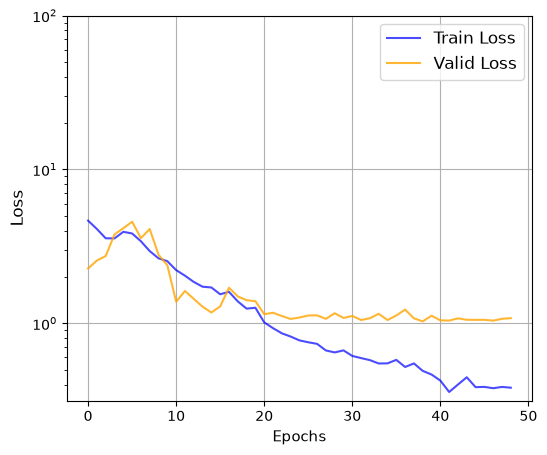

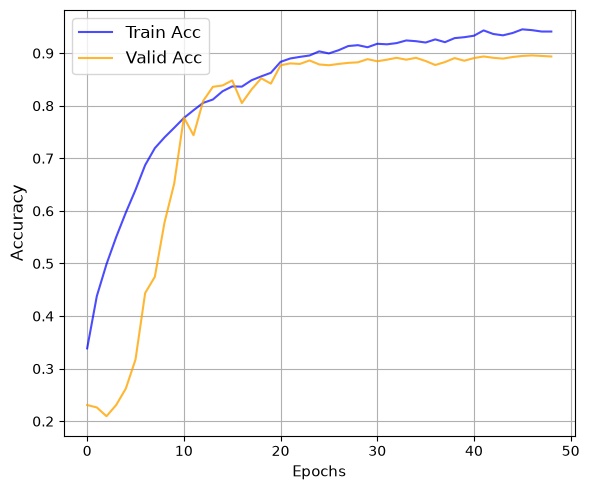

In [37]:
loss = history.history['loss']
v_loss = history.history['val_loss']
acc = history.history['accuracy']
v_acc = history.history['val_accuracy']
epochs = range(len(loss))

# Plot Loss Curves
fig = plt.figure(figsize=(6, 5))
plt.yscale('log')
plt.plot(epochs, loss, color='blue', alpha=0.7, label='Train Loss')
plt.plot(epochs, v_loss, color='orange', alpha=0.8, label='Valid Loss')
plt.ylim(-0.3, 100)
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid()
plt.show()

# Plot Accuracy Curves
fig = plt.figure(figsize=(6, 5))
plt.plot(epochs, acc, color='blue', alpha=0.7, label='Train Acc')
plt.plot(epochs, v_acc, color='orange', alpha=0.8, label='Valid Acc')
plt.xlabel('Epochs', fontsize=11)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.grid()
plt.show()

In [42]:
y_pred = np.argmax(model.predict(X_test), axis=1)

submission = pd.DataFrame({
    "Id": X_test_ids,
    "Label": y_pred
})

submission['Label'] = submission['Label'].apply(lambda x: int_to_class[x])

submission.to_csv("submission.csv", index=False)

309/309 [==============================] - 3s 10ms/step


In [44]:
y_pred = np.argmax(model.predict(X_train), axis=1)

submission = pd.DataFrame({
    "Id": X_train_ids,
    "Labelpred": y_pred,
    'label0rg': y_train
})
submission.to_csv("submission2.csv", index=False)

309/309 [==============================] - 3s 10ms/step


In [45]:
print(len(submission[submission['Labelpred']!=submission['label0rg']])/len(submission), ' wrong')
print(len(submission[submission['Labelpred']==submission['label0rg']])/len(submission), ' correct')

0.044336471302763435  wrong
0.9556635286972366  correct


In [25]:
LabelEncoder()

LabelEncoder()

In [26]:
# X_tiny = X_train[:32]
# y_tiny = y_train[:32]

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

# # If the setup works, accuracy MUST hit 100% (1.0) within 30-50 epochs
# model.fit(X_tiny, y_tiny, epochs=50, batch_size=32)

In [27]:
print(X_train.max())

1.0


In [28]:
# 1. Check label range and unique values
import numpy as np
print("Labels shape:", y_train.shape)
print("Unique label values:", np.unique(y_train))  # MUST be array([0, 1, 2, 3, 4, 5, 6])

# 2. Check image array dimensions
print("Images shape:", X_train.shape)  # Last number should be channels (e.g. 1 or 3)

# 3. Check trainable parameters
print("Trainable params:", sum([np.prod(v.get_shape().as_list()) for v in model.trainable_weights]))

Labels shape: (9879,)
Unique label values: [0 1 2 3 4 5 6]
Images shape: (9879, 72, 72, 1)
Trainable params: 1142727
